# set_analysis_v2 — SET vs Random-Sparse (stationary & non-stationary)

Pulls the `set-analysis-sweep-v2` Comet sweeps and plots, for **both** the
stationary and non-stationary regimes:

- **Random-Sparse**: asymptotic-loss sensitivity over learning rate.
- **SET**: sensitivity over **learning rate** and over **zeta**, with
  `prune_metric` as the hue, in **separate figures per `init_mode`**
  (`epsilon`, `uniform_p`). Each LR point uses the best `(zeta, target_hidden_units)`;
  each zeta point uses the best `(learning_rate, target_hidden_units)`.
- **SET static (zeta=0)** baseline: the `*_set_static` sweeps run SET with
  `zeta=0`, so no connection is ever pruned/regrown -- the net is frozen at its
  SET-init sparse topology. It's a random-sparse-style static baseline whose
  sparsity is generated by SET's ER init. It is overlaid as an extra line on the
  SET LR-sensitivity, a horizontal reference on the zeta-sensitivity (the
  zeta -> 0 limit), and a third curve in the learning curves.
- **Learning curves** of the single best configuration per method.

8 tasks at the 25,408-weight block-sparse budget; 5 seeds vmapped per trial.
Metric is the sweep objective: `asymptotic_test_loss` (stationary, held-out test
eval) / `asymptotic_loss` (non-stationary, no test split), lower = better.

**NaN handling.** Each cell is one vmapped-5-seed trial, so its asymptotic
summary is read directly. Diverged trials are set to NaN and *kept* (never
silently dropped); a "best over nuisance" point is NaN -- a visible gap -- only
when every nuisance combination at that point diverged.

In [2]:
# # Run once to fetch from Comet. Comment out after first run. Picks up the
# # *_set_static sweeps automatically once they have completed trials.
# from phd.research_utils.scripts.comet_download import run as _comet_download
# _comet_download('set-analysis-sweep-v2', output_dir='data',
#                 include_running=True, include_crashed=True, discovery_samples=10_000)

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from phd.research_utils.analysis.analysis_utils import (
    set_matplotlib_style, get_color_palette, save_fig_versions,
)

set_matplotlib_style('2-row')
%matplotlib inline

PROJECT  = 'set-analysis-sweep-v2'
DATA_DIR = Path('data')
N_TASKS  = 8

# Two regimes x methods. `metric` is the sweep objective for that regime.
# `set_static` is the zeta=0 (no-evolution) baseline.
SWEEPS = {
    'stationary': {
        'random_sparse': 'stationary_random_sparse',
        'set':           'stationary_set',
        'set_static':    'stationary_set_static',
        'metric':        'asymptotic_test_loss',
        'metric_label':  'Asymptotic test loss',
    },
    'nonstationary': {
        'random_sparse': 'nonstationary_random_sparse',
        'set':           'nonstationary_set',
        'set_static':    'nonstationary_set_static',
        'metric':        'asymptotic_loss',
        'metric_label':  'Asymptotic loss',
    },
}

def save_fig(name):
    save_fig_versions(name, dir='figures/pdf/', type='pdf')
    save_fig_versions(name, dir='figures/png/', type='png')

In [4]:
cfg_all = pd.read_csv(DATA_DIR / f'{PROJECT}_params.csv', index_col=0)
run_all = pd.read_csv(DATA_DIR / f'{PROJECT}_metrics.csv', index_col=0)

# optimizer.learning_rate (dotted) is the raw CLI override string
# ('${eval:2**-9}'); the pipe form is the resolved float. Use the pipe form.
cfg_all['learning_rate'] = pd.to_numeric(cfg_all['optimizer|learning_rate'], errors='coerce')

for c in ['set.zeta', 'set.utility_decay', 'set.connection_budget', 'target_hidden_units',
          'task.n_tasks', 'task.permute_period', 'train.eval_freq', 'model.initial_hidden_units']:
    if c in cfg_all.columns:
        cfg_all[c] = pd.to_numeric(cfg_all[c], errors='coerce')

# comet_download's metrics CSV has no explicit step column; rows are pre-sorted
# per run by Comet's step index. Reconstruct step = (row position) * log_freq
# (log_freq = 1000 for every run here).
LOG_FREQ = 1000
run_all = run_all.reset_index(drop=True)
run_all['step'] = (run_all.groupby('run_id').cumcount() + 1) * LOG_FREQ

print(f'{len(cfg_all)} trials, {len(run_all)} metric rows')
print(cfg_all['sweep_name'].value_counts())

683 trials, 340103 metric rows
sweep_name
stationary_set                 308
nonstationary_set              304
nonstationary_set_static        30
stationary_set_static           30
stationary_random_sparse         6
nonstationary_random_sparse      5
Name: count, dtype: int64


In [5]:
def _last(s):
    """Last non-NaN value of a series (the asymptotic summary is logged once)."""
    s = s.dropna()
    return s.iloc[-1] if len(s) else np.nan


def load_sweep(sweep_name, cell_cols, metric_col):
    """Slice cfg+run to one sweep, dedupe Comet retries per experimental cell,
    and attach the per-run asymptotic `_metric` (NaN if the trial diverged).

    Each cell is a single vmapped-5-seed trial. Retries (a cell logged more than
    once after a timeout/crash) are deduped by keeping the most-complete trial
    (most metric rows). Diverged trials keep their row but get `_metric = NaN`,
    so they are never silently omitted: a point is a gap only when *all* of its
    nuisance combinations diverged. Returns empty frames if the sweep has no
    data yet (e.g. set_static before its CC jobs finish).
    """
    cfg = cfg_all[cfg_all['sweep_name'] == sweep_name].copy()
    run = run_all[run_all['run_id'].isin(cfg['run_id'])].copy()
    if len(cfg) == 0:
        cfg['_metric'] = pd.Series(dtype=float)
        return cfg, run

    n_rows = run.groupby('run_id').size().rename('_n_rows')
    div = (run.groupby('run_id')['diverged'].apply(_last).rename('_div')
           if 'diverged' in run.columns else pd.Series(dtype=float, name='_div'))
    asym = run.groupby('run_id')[metric_col].apply(_last).rename('_metric')

    cfg = (cfg.merge(n_rows, left_on='run_id', right_index=True, how='left')
              .merge(div,    left_on='run_id', right_index=True, how='left')
              .merge(asym,   left_on='run_id', right_index=True, how='left'))
    cfg['_n_rows'] = cfg['_n_rows'].fillna(0).astype(int)
    cfg['_div'] = cfg['_div'].fillna(0)
    cfg.loc[cfg['_div'] > 0.5, '_metric'] = np.nan

    cfg = cfg.sort_values('_n_rows', ascending=False).drop_duplicates(cell_cols, keep='first')
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    return cfg, run


def best_over(cfg, x_col, hue_col=None, direction='min'):
    """Best `_metric` per (hue, x) group, optimizing over all other (nuisance)
    columns. pandas min/max skip NaN within a group and return NaN only when the
    whole group is NaN -> the line shows a gap there (diverged points can't win).
    """
    if len(cfg) == 0:
        return pd.DataFrame(columns=([hue_col] if hue_col else []) + [x_col, '_metric'])
    keys = ([hue_col] if hue_col else []) + [x_col]
    agg = 'min' if direction == 'min' else 'max'
    return cfg.groupby(keys)['_metric'].agg(agg).reset_index()


STATIC_COLOR = 'black'

def plot_sensitivity(agg, x_col, hue_col, title, xlabel, ylabel, save_name,
                     x_mode='pow2', palette=None, hue_label=None,
                     static_line=None, static_hline=None):
    """Sensitivity line plot. x_mode: 'pow2' (log2 LR axis) or 'even' (evenly
    spaced categorical, e.g. zeta). NaN `_metric` values break the line (gap).

    static_line: optional df [x_col, '_metric'] drawn as a black dashed
        'static (zeta=0)' line, using the same x positions.
    static_hline: optional scalar drawn as a black dashed horizontal reference.
    """
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    x_vals = sorted(agg[x_col].dropna().unique())
    pos = {v: i for i, v in enumerate(x_vals)} if x_mode == 'even' else None

    def _x(series):
        return series.map(pos) if pos is not None else series

    if hue_col is None:
        sub = agg.sort_values(x_col)
        ax.plot(_x(sub[x_col]), sub['_metric'], '-o', color='C0')
    else:
        hue_vals = sorted(agg[hue_col].dropna().unique(), key=str)
        colors = palette or sns.color_palette('tab10', len(hue_vals))
        for hv, color in zip(hue_vals, colors):
            sub = agg[agg[hue_col] == hv].sort_values(x_col)
            ax.plot(_x(sub[x_col]), sub['_metric'], '-o', color=color, label=str(hv))

    if static_line is not None and len(static_line) and static_line['_metric'].notna().any():
        sub = static_line.sort_values(x_col)
        ax.plot(_x(sub[x_col]), sub['_metric'], '--s', color=STATIC_COLOR,
                label='static (ζ=0)')
    if static_hline is not None and np.isfinite(static_hline):
        ax.axhline(static_hline, linestyle='--', color=STATIC_COLOR,
                   label='static (ζ=0)')

    if hue_col is not None or static_line is not None or static_hline is not None:
        ax.legend(title=hue_label or (hue_col.split('.')[-1].replace('_', ' ') if hue_col else None))

    if x_mode == 'pow2':
        ax.set_xscale('log', base=2)
        ax.set_xticks(x_vals)
        ax.set_xticklabels([f'$2^{{{int(np.log2(v))}}}$' for v in x_vals])
    elif x_mode == 'even':
        ax.set_xticks(list(pos.values()))
        ax.set_xticklabels([f'{v:g}' for v in x_vals])

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    save_fig(save_name)
    plt.show()


# Cell-coordinate registries (params that define a unique experimental cell).
RS_CELL     = ['learning_rate']
SET_CELL    = ['set.init_mode', 'set.prune_metric', 'set.zeta',
               'target_hidden_units', 'learning_rate']
STATIC_CELL = ['set.init_mode', 'target_hidden_units', 'learning_rate']
PRUNE_PALETTE = get_color_palette(classes=['magnitude', 'utility'])
PRUNE_ORDER   = ['magnitude', 'utility']

## Random-Sparse — learning-rate sensitivity

Sparsity / width are fixed (183 units at the 2-task winning sparsity), so LR is
the only swept axis. A gap means that LR diverged.

/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')


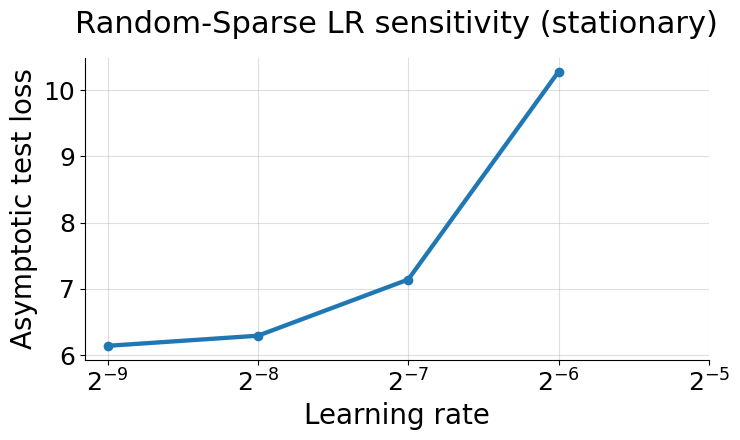

[stationary] random_sparse: 5 cells, 1 diverged (NaN)
 learning_rate  _metric  log2_lr
         0.002    6.141     -9.0
         0.004    6.294     -8.0
         0.008    7.142     -7.0
         0.016   10.280     -6.0
         0.031      NaN     -5.0


/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')


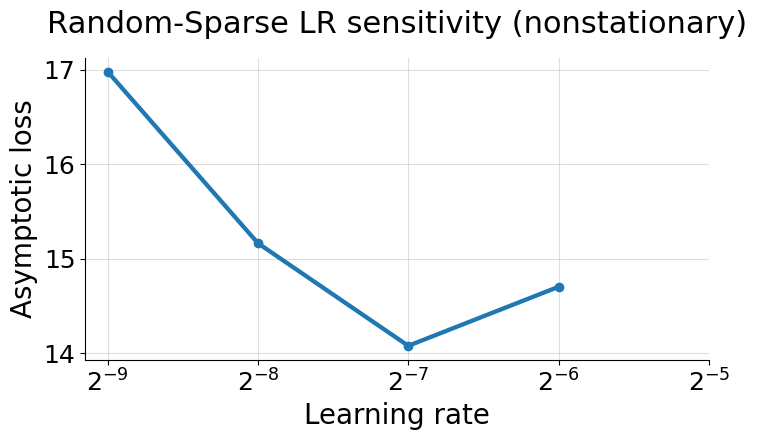

[nonstationary] random_sparse: 5 cells, 1 diverged (NaN)
 learning_rate  _metric  log2_lr
         0.002   16.980     -9.0
         0.004   15.165     -8.0
         0.008   14.080     -7.0
         0.016   14.704     -6.0
         0.031      NaN     -5.0


In [6]:
for regime, S in SWEEPS.items():
    cfg, run = load_sweep(S['random_sparse'], RS_CELL, S['metric'])
    agg = best_over(cfg, 'learning_rate')
    plot_sensitivity(
        agg, 'learning_rate', None,
        title=f'Random-Sparse LR sensitivity ({regime})',
        xlabel='Learning rate', ylabel=S['metric_label'],
        save_name=f'rs_lr_sensitivity_{regime}', x_mode='pow2',
    )
    print(f'[{regime}] random_sparse: {len(cfg)} cells, '
          f'{cfg["_metric"].isna().sum()} diverged (NaN)')
    print(agg.assign(log2_lr=np.log2(agg['learning_rate'])).round(3).to_string(index=False))

## SET — learning-rate and zeta sensitivity, by `init_mode`

For each regime and each `init_mode` (`epsilon`, `uniform_p`), two sensitivity
plots with `prune_metric` as the hue, plus the **static (zeta=0)** baseline:

- **LR sensitivity**: each point = best over `(zeta, target_hidden_units)`;
  the static line is best over `target_hidden_units` at each LR.
- **zeta sensitivity**: each point = best over `(learning_rate, target_hidden_units)`;
  the static dashed line is best over `(learning_rate, target_hidden_units)`
  (the zeta -> 0 limit).

=== stationary SET: 300 cells, 0 diverged  |  set_static: 30 cells ===


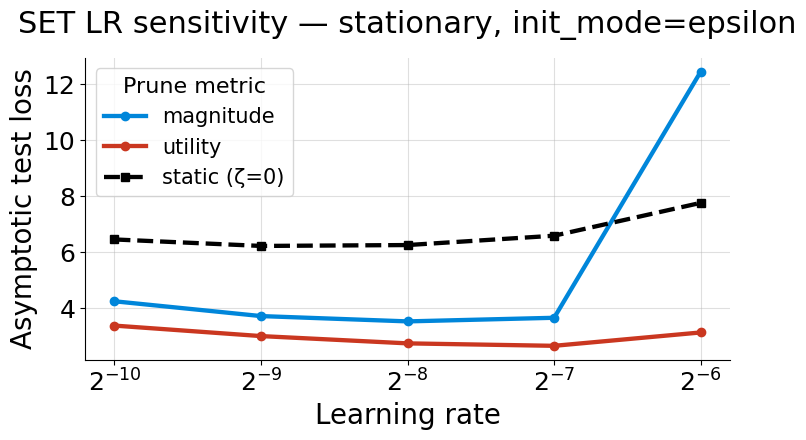

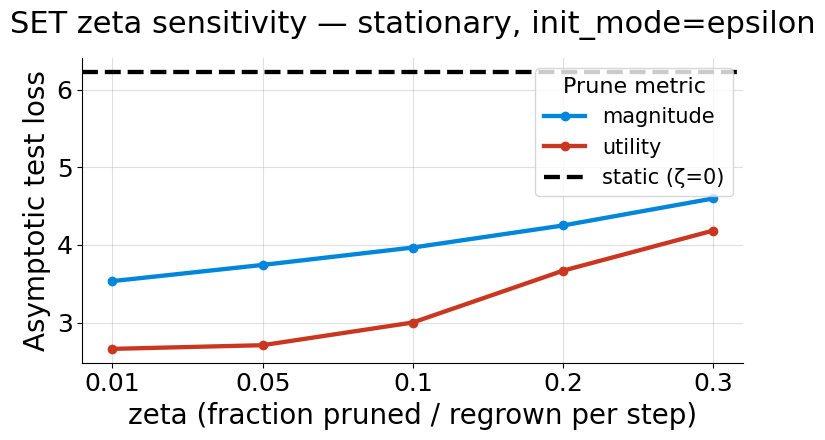

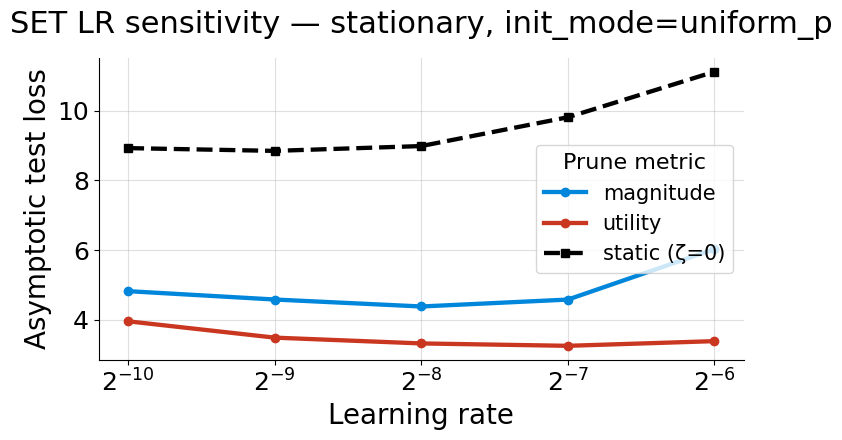

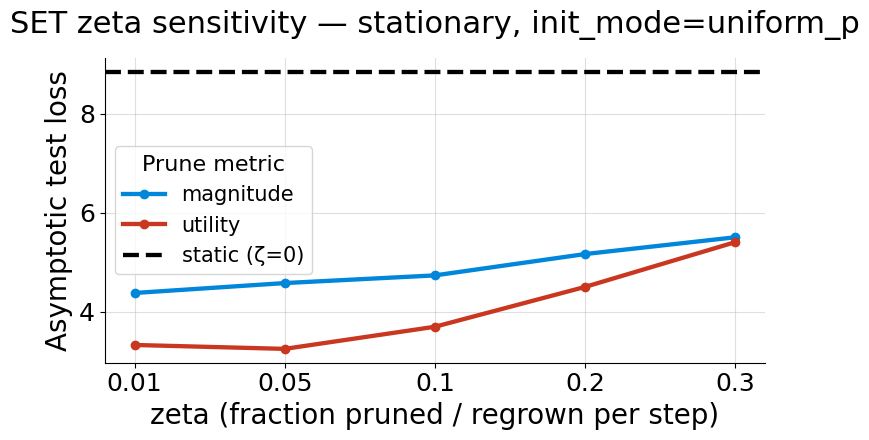

=== nonstationary SET: 300 cells, 4 diverged  |  set_static: 30 cells ===


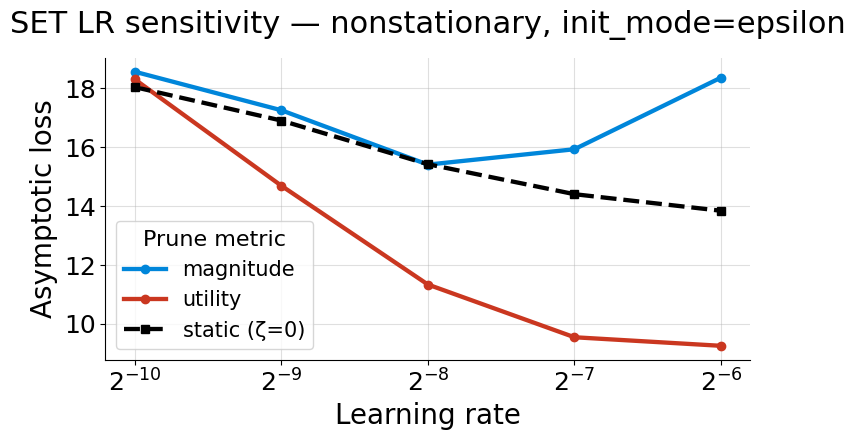

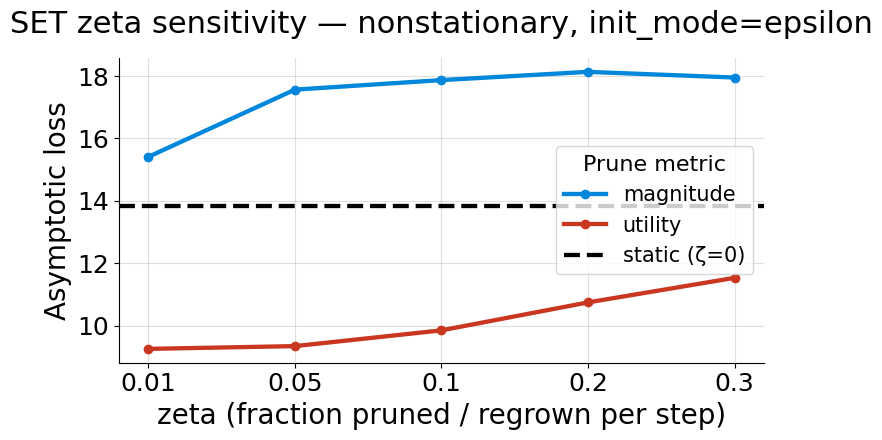

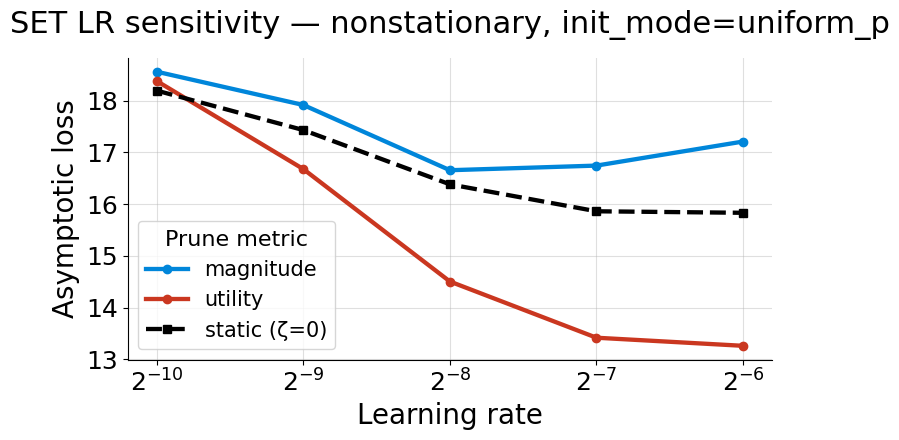

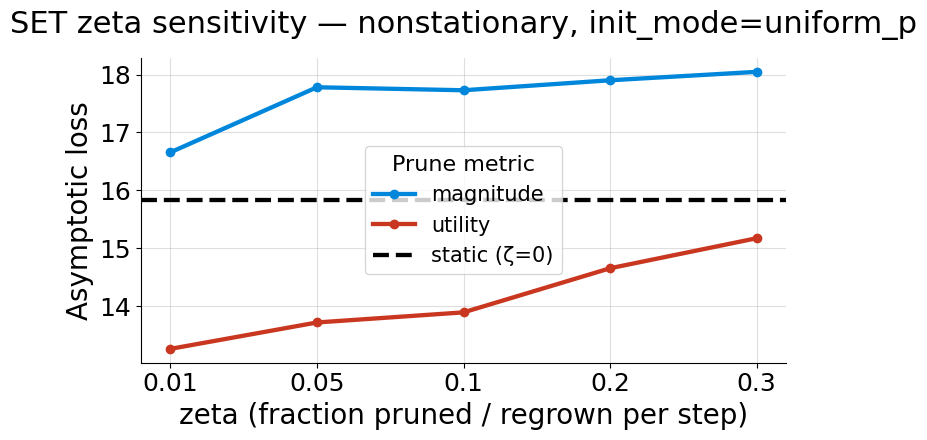

In [7]:
for regime, S in SWEEPS.items():
    cfg, run = load_sweep(S['set'], SET_CELL, S['metric'])
    stat_cfg, _ = load_sweep(S['set_static'], STATIC_CELL, S['metric'])
    n_static = len(stat_cfg)
    print(f'=== {regime} SET: {len(cfg)} cells, {cfg["_metric"].isna().sum()} diverged'
          f'  |  set_static: {n_static} cells'
          + ('' if n_static else '  (no data yet -- baseline skipped)') + ' ===')

    for init_mode in ['epsilon', 'uniform_p']:
        sub = cfg[cfg['set.init_mode'] == init_mode]
        stat_sub = stat_cfg[stat_cfg['set.init_mode'] == init_mode] if n_static else stat_cfg

        # LR sensitivity (best over zeta + target_hidden_units), hue=prune_metric.
        # static line = best over target_hidden_units at each LR.
        agg_lr = best_over(sub, 'learning_rate', hue_col='set.prune_metric')
        static_lr = best_over(stat_sub, 'learning_rate') if n_static else None
        plot_sensitivity(
            agg_lr, 'learning_rate', 'set.prune_metric',
            title=f'SET LR sensitivity — {regime}, init_mode={init_mode}',
            xlabel='Learning rate', ylabel=S['metric_label'],
            save_name=f'set_lr_sensitivity_{regime}_{init_mode}',
            x_mode='pow2', palette=[PRUNE_PALETTE[p] for p in PRUNE_ORDER],
            hue_label='Prune metric', static_line=static_lr,
        )

        # zeta sensitivity (best over learning_rate + target_hidden_units).
        # static dashed reference = best over (LR, hidden) for this init_mode.
        agg_z = best_over(sub, 'set.zeta', hue_col='set.prune_metric')
        static_h = (stat_sub['_metric'].min() if n_static and stat_sub['_metric'].notna().any()
                    else None)
        plot_sensitivity(
            agg_z, 'set.zeta', 'set.prune_metric',
            title=f'SET zeta sensitivity — {regime}, init_mode={init_mode}',
            xlabel='zeta (fraction pruned / regrown per step)', ylabel=S['metric_label'],
            save_name=f'set_zeta_sensitivity_{regime}_{init_mode}',
            x_mode='even', palette=[PRUNE_PALETTE[p] for p in PRUNE_ORDER],
            hue_label='Prune metric', static_hline=static_h,
        )

## Learning curves of the best configuration

Best = lowest asymptotic objective for that regime, chosen over **all** swept
axes. The **SET static (zeta=0)** baseline is added as a third curve once its
sweeps have data. Curves are the dense across-seed training `loss`/`accuracy`
time series (shaded band = across-seed std); per-task loss = `loss / n_tasks`.

=== stationary best configs (asymptotic_test_loss) ===
  Random-Sparse : Random-Sparse (lr=2^-9)  -> 6.141
  SET           : SET (epsilon, utility, $\zeta$=0.01, H=384, lr=2^-7)  -> 2.663
  SET static    : SET static ζ=0 (epsilon, H=384, lr=2^-9)  -> 6.228


/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')


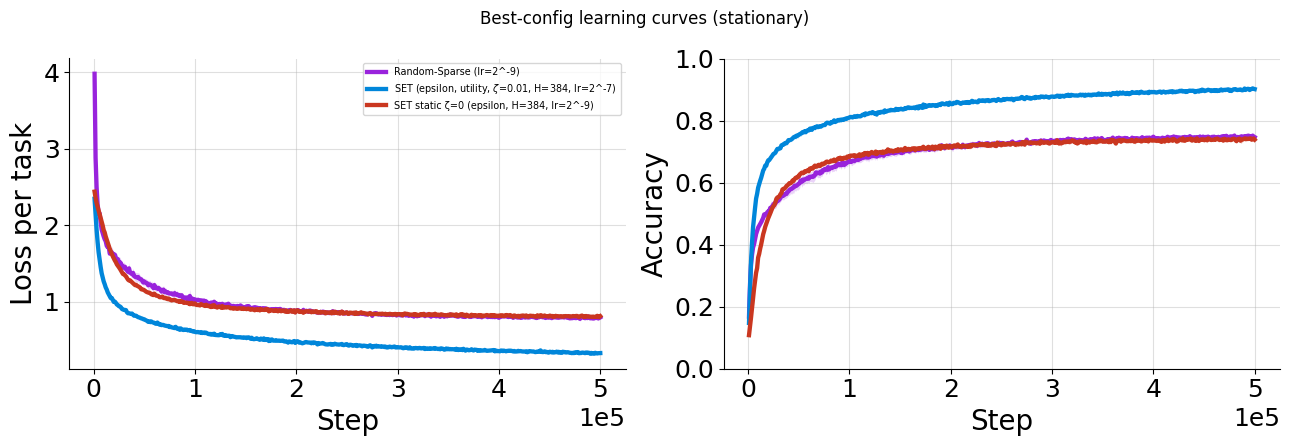

=== nonstationary best configs (asymptotic_loss) ===
  Random-Sparse : Random-Sparse (lr=2^-7)  -> 14.080
  SET           : SET (epsilon, utility, $\zeta$=0.01, H=384, lr=2^-6)  -> 9.256
  SET static    : SET static ζ=0 (epsilon, H=384, lr=2^-6)  -> 13.844


/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')
/home/edan/local_projects/phd_research/phd/research_utils/analysis/analysis_utils.py:242: UserWarning: No legend found
  warnings.warn('No legend found')


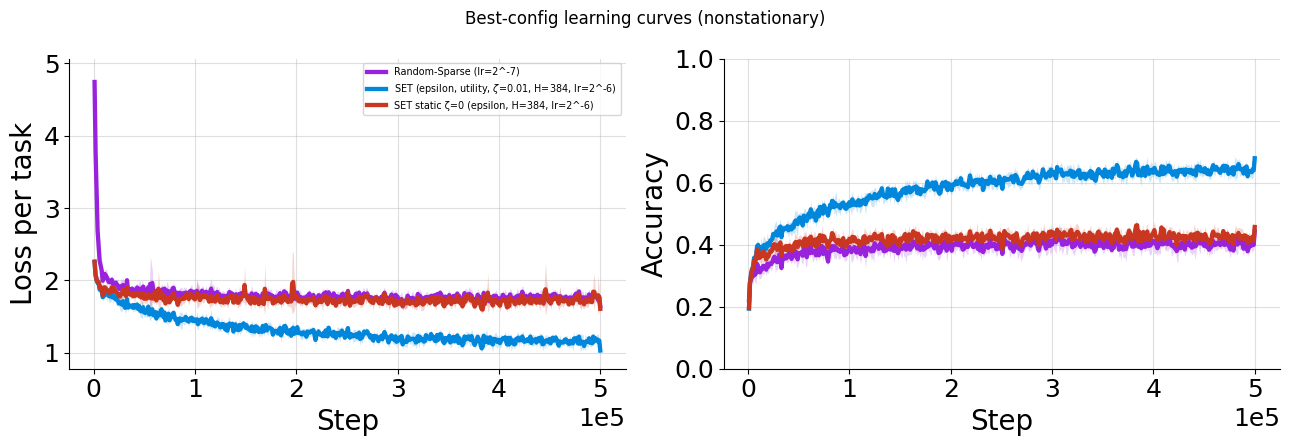

In [8]:
def best_cfg_row(cfg):
    """Row of the best (lowest `_metric`) configuration; NaN/diverged excluded.
    Returns None if there is no valid run yet."""
    valid = cfg.dropna(subset=['_metric'])
    if len(valid) == 0:
        return None
    return valid.loc[valid['_metric'].idxmin()]


def _curve(ax, run, run_id, y_col, std_col, scale, label, color):
    sub = run[run['run_id'] == run_id].sort_values('step')
    x = sub['step'].values
    y = sub[y_col].values / scale
    ax.plot(x, y, label=label, color=color)
    if std_col in sub.columns:
        s = sub[std_col].values / scale
        ax.fill_between(x, y - s, y + s, alpha=0.2, color=color, linewidth=0)


def _label(method, row):
    lr = f'2^{int(np.log2(row["learning_rate"]))}'
    if method == 'Random-Sparse':
        return f'Random-Sparse (lr={lr})'
    if method == 'SET static':
        return (f'SET static ζ=0 ({row["set.init_mode"]}, '
                f'H={int(row["target_hidden_units"])}, lr={lr})')
    return (f'SET ({row["set.init_mode"]}, {row["set.prune_metric"]}, '
            f'$\\zeta$={row["set.zeta"]:g}, H={int(row["target_hidden_units"])}, lr={lr})')


METHOD_PALETTE = get_color_palette(
    classes=['Random-Sparse', 'SET', 'SET static (ζ=0)'])

for regime, S in SWEEPS.items():
    methods = []
    rs_cfg,  rs_run  = load_sweep(S['random_sparse'], RS_CELL,  S['metric'])
    set_cfg, set_run = load_sweep(S['set'],           SET_CELL, S['metric'])
    stat_cfg, stat_run = load_sweep(S['set_static'],  STATIC_CELL, S['metric'])
    for name, cfg, run, key in [
        ('Random-Sparse',     rs_cfg,   rs_run,   'Random-Sparse'),
        ('SET',               set_cfg,  set_run,  'SET'),
        ('SET static',        stat_cfg, stat_run, 'SET static (ζ=0)'),
    ]:
        row = best_cfg_row(cfg)
        if row is not None:
            methods.append((name, key, row, run))

    print(f'=== {regime} best configs ({S["metric"]}) ===')
    for name, key, row, _ in methods:
        print(f'  {name:14s}: {_label(name, row)}  -> {row["_metric"]:.3f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, (y_col, std_col, scale, ylab) in zip(
        axes, [('loss', 'loss_std', N_TASKS, 'Loss per task'),
               ('accuracy', 'accuracy_std', 1.0, 'Accuracy')]):
        for name, key, row, run in methods:
            _curve(ax, run, row['run_id'], y_col, std_col, scale,
                   _label(name, row), METHOD_PALETTE[key])
        ax.set_xlabel('Step'); ax.set_ylabel(ylab); ax.grid(True, alpha=0.4)
        ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
    axes[1].set_ylim(0, 1)
    axes[0].legend(fontsize='x-small', loc='best')
    fig.suptitle(f'Best-config learning curves ({regime})')
    plt.tight_layout()
    save_fig(f'best_learning_curves_{regime}')
    plt.show()